In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
df=pd.read_csv('dataset.csv')
df.head()

,text_type,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,4 color printing special request additional in...
4,spam,do not have money get software cds from here s...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20348 entries, 0 to 20347
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text_type  20348 non-null  object
 1   text       20348 non-null  object
dtypes: object(2)
memory usage: 318.1+ KB


# Handle Missing & Duplicated Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({
'Missing Count' : missing,
'Missing %'     : missing_pct
}).query('`Missing Count` > 0')

print("Missing Values:")
print(quality_report.to_string())
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
Duplicate rows: 14


In [5]:
# remove Duplicate rows
df.drop_duplicates(inplace=True)
print(f"Duplicate rows after removal: {df.duplicated().sum()}")

Duplicate rows after removal: 0


# Text Cleaning

In [6]:
Words_dict = {
    'u': 'you',
    'ur': 'your',
    'r': 'are',
    '4u': 'for you',
    'gr8': 'great',
    'b4': 'before',
    'plz': 'please',
    'msg': 'message',
    'txt': 'text',
}

def replace_words(text):
    text = text.lower()
    words = text.split()
    new_words = [Words_dict.get(word, word) for word in words]
    return " ".join(new_words)

df['text'] = df['text'].apply(replace_words)

In [7]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'(http|https):\/\/[\w\-]+(\.[\w\-]+)+([\w\-\.,@?^=%&:/~\+#]*[\w\-\@?^=%&/~\+#])?', ' <url> ', text)

    text = re.sub(r'£|\$|€', ' <cur> ', text)
    text = re.sub(r'\b\d+\b', ' <num> ', text)

    text = re.sub(r'[^a-z\s<>]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['text'] = df['text'].apply(clean_text)
df.head()

,text_type,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,<num> color printing special request additiona...
4,spam,do not have money get software cds from here s...


<Axes: xlabel='text_type'>

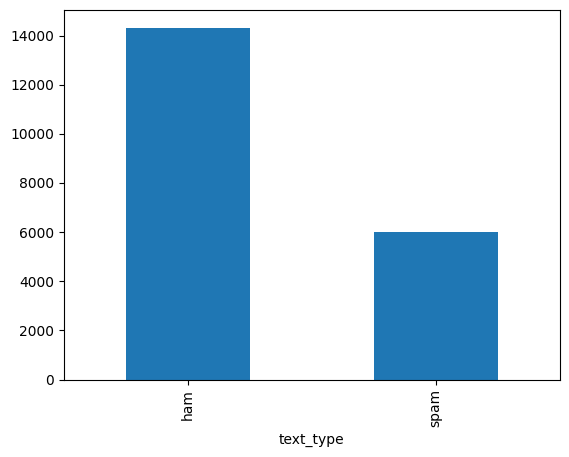

In [8]:
df['text_type'].value_counts().plot(kind='bar')

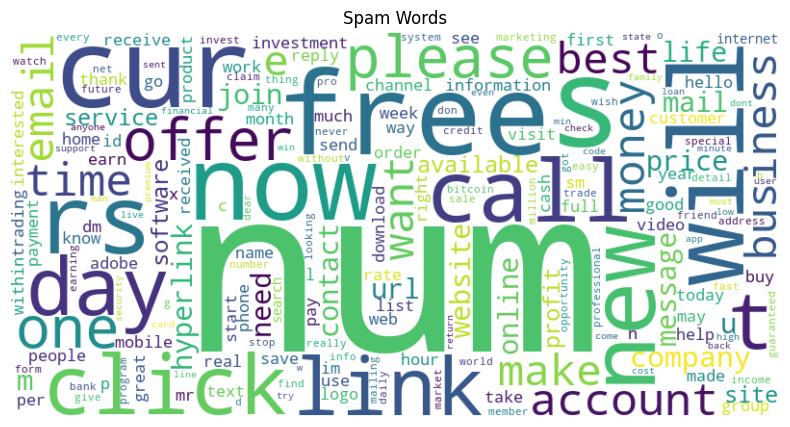

In [9]:
spam_text = " ".join(df[df['text_type'] == 'spam']['text'])

wordcloud_spam = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title("Spam Words")
plt.axis("off")
plt.show()

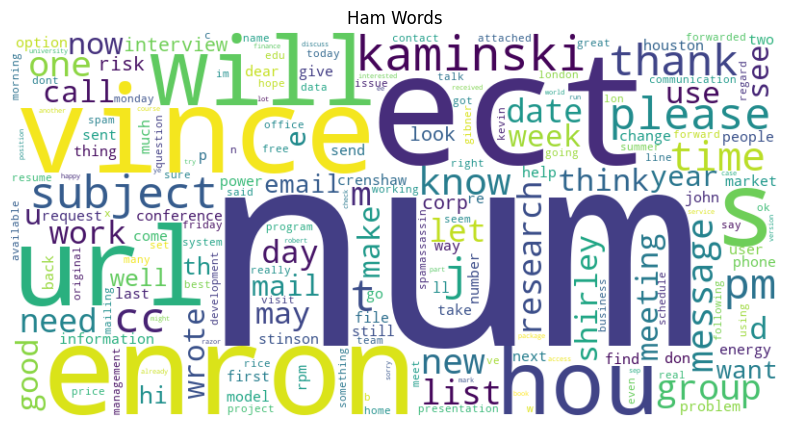

In [10]:
ham_text = " ".join(df[df['text_type'] == 'ham']['text'])

wordcloud_ham = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title("Ham Words")
plt.axis("off")
plt.show()

# Preprocessing

In [11]:
# Import required libraries

import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

In [12]:
# Download NLTK resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mostafa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mostafa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mostafa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Mostafa\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Mostafa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Mostafa\AppData\Roaming\nltk_data...
[nltk_data]   Package

True

In [13]:
import re

def custom_tokenize(text):

    pattern = r'<num>|<url>|<cur>|[\w]+'
    tokens = re.findall(pattern, text)
    return tokens

In [14]:
df['tokens'] = df['text'].apply(custom_tokenize)

In [15]:
# Remove common stopwords

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [16]:
import re

def is_special_token(word):
    return (
        re.match(r'^https?://', word) or
        re.match(r'^\S+@\S+\.\S+$', word) or
        word.isdigit()
    )

In [17]:
# Apply stemming

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df['stemmed_tokens'] = df['tokens'].apply(
    lambda words: [
        stemmer.stem(word) if not is_special_token(word) else word
        for word in words
    ]
)

In [18]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    """Map NLTK Treebank POS tag to WordNet POS tag for lemmatization"""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_tokens_with_pos(tokens_list):

    tagged_tokens = pos_tag(tokens_list)

    lemmatized_words = []
    for word, tag in tagged_tokens:
        if not is_special_token(word):

            lemmatized_words.append(lemmatizer.lemmatize(word, pos=get_wordnet_pos(tag)))
        else:
            lemmatized_words.append(word)
    return lemmatized_words

df['lemmatized_tokens'] = df['tokens'].apply(lemmatize_tokens_with_pos)

In [19]:
# Compare stemming vs lemmatization side by side

comparison_df = pd.DataFrame({
    "original": df['tokens'].explode(),
    "stemmed": df['stemmed_tokens'].explode(),
    "lemmatized": df['lemmatized_tokens'].explode()
})

comparison_df.head(200)

,original,stemmed,lemmatized
0,naturally,natur,naturally
0,irresistible,irresist,irresistible
0,corporate,corpor,corporate
0,identity,ident,identity
0,lt,lt,lt
...,...,...,...
3,pdf,pdf,pdf
3,format,format,format
3,phone,phone,phone
3,<num>,<num>,<num>


In [20]:
# Calculate unique vocabulary size

original_vocab = len(set(df['tokens'].explode()))
stemmed_vocab = len(set(df['stemmed_tokens'].explode()))
lemmatized_vocab = len(set(df['lemmatized_tokens'].explode()))

print("Original Vocabulary Size:", original_vocab)
print("Stemmed Vocabulary Size:", stemmed_vocab)
print("Lemmatized Vocabulary Size:", lemmatized_vocab)

Original Vocabulary Size: 47362
Stemmed Vocabulary Size: 37763
Lemmatized Vocabulary Size: 42797


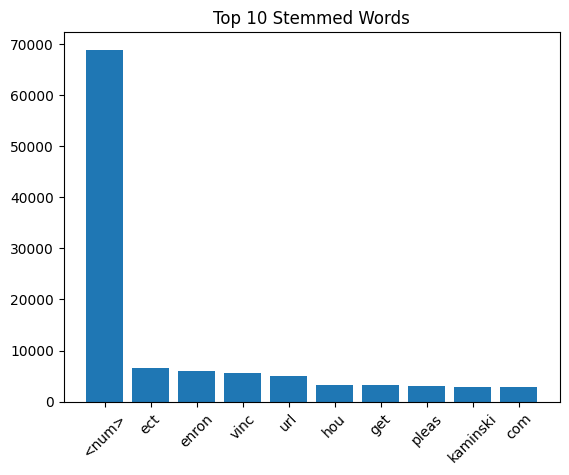

In [21]:
# Plot top 10 frequent stemmed words

from collections import Counter
import matplotlib.pyplot as plt

stem_words = df['stemmed_tokens'].explode()
stem_counts = Counter(stem_words)
top_stem = stem_counts.most_common(10)

words, counts = zip(*top_stem)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Stemmed Words")
plt.show()

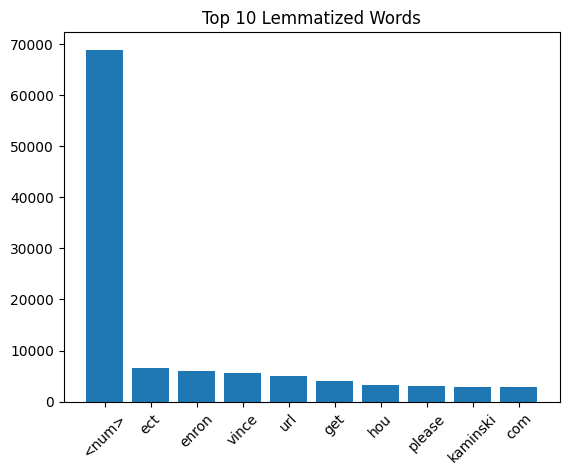

In [22]:
# Plot top 10 frequent lemmatized words

lemma_words = df['lemmatized_tokens'].explode()
lemma_counts = Counter(lemma_words)
top_lemma = lemma_counts.most_common(10)

words, counts = zip(*top_lemma)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Lemmatized Words")
plt.show()

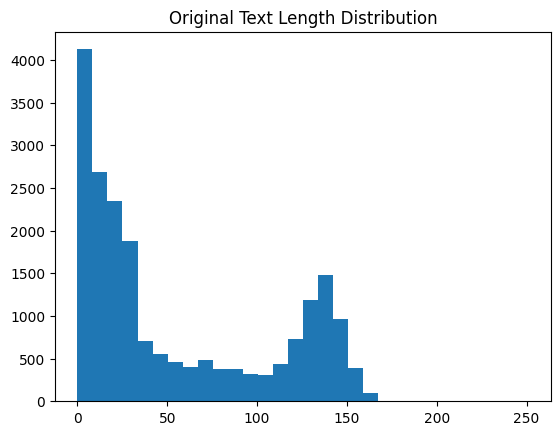

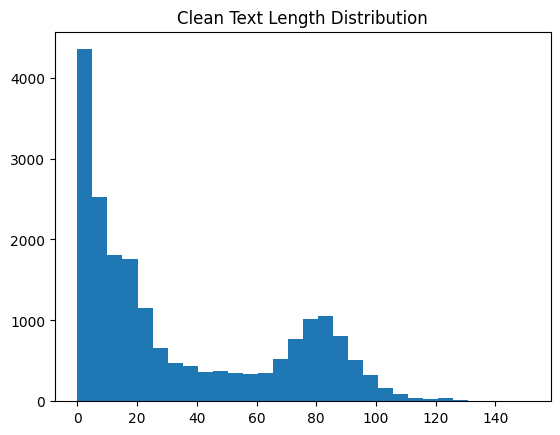

In [23]:
# Join lemmatized tokens into final clean text
df['clean_text'] = df['lemmatized_tokens'].apply(
    lambda words: " ".join(words)
)

# Compare message length before and after preprocessing

df['original_length'] = df['text'].str.split().apply(len)
df['clean_length'] = df['clean_text'].str.split().apply(len)

import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['original_length'], bins=30)
plt.title("Original Text Length Distribution")
plt.show()

plt.figure()
plt.hist(df['clean_length'], bins=30)
plt.title("Clean Text Length Distribution")
plt.show()

In [24]:
# Join lemmatized tokens into final clean text

df['clean_text'] = df['lemmatized_tokens'].apply(
    lambda words: " ".join(words)
)

# TF-IDF (Unigrams)

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)
X1 = tfidf.fit_transform(df['clean_text'])

In [26]:
print(X1.shape)
print(tfidf.get_feature_names_out()[:20])

(20334, 3000)
['aa' 'aap' 'ab' 'ability' 'able' 'absolutely' 'abstract' 'abt' 'ac'
 'academic' 'accept' 'acceptable' 'access' 'accomplish' 'accord' 'account'
 'accounting' 'accuracy' 'accurate' 'achieve']


In [27]:
import pandas as pd

df_tfidf = pd.DataFrame(
    X1.toarray(),
    columns=tfidf.get_feature_names_out()
)

df_tfidf.head(10)

,aa,aap,ab,ability,able,absolutely,abstract,abt,ac,academic,...,youre,youtube,yr,yup,ze,zero,zhang,zimin,zip,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.246007,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
print("Non-zero values:", (X1 != 0).sum())
print("Total values:", X1.shape[0] * X1.shape[1])
print("Non-zero ratio:", ((X1 != 0).sum())/(X1.shape[0] * X1.shape[1]))

Non-zero values: 405110
Total values: 61002000
Non-zero ratio: 0.0066409298055801445


In [29]:
import numpy as np

sparsity = np.mean(X1.toarray() == 0)
print("Sparsity:", sparsity)

Sparsity: 0.9933590701944198


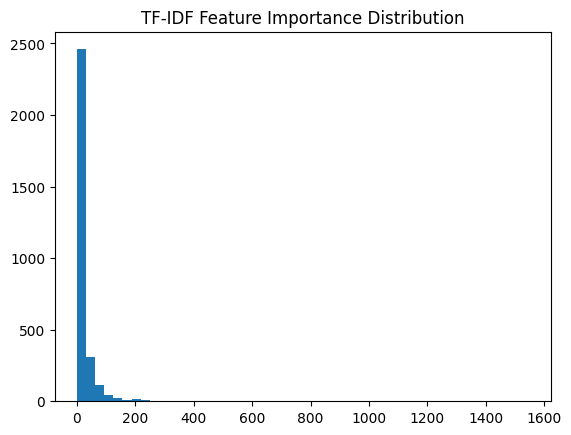

In [30]:
import matplotlib.pyplot as plt

plt.hist(np.sum(X1.toarray(), axis=0), bins=50)
plt.title("TF-IDF Feature Importance Distribution")
plt.show()

##Count Vectorizer (Unigrams)

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(
    max_features=3000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.90
)
X2 = count_vec.fit_transform(df['clean_text'])

In [32]:
print(X2.shape)
print(count_vec.get_feature_names_out()[:20])

(20334, 3000)
['aa' 'aap' 'ab' 'ability' 'able' 'absolutely' 'abstract' 'abt' 'ac'
 'academic' 'accept' 'acceptable' 'access' 'accomplish' 'accord' 'account'
 'accounting' 'accuracy' 'accurate' 'achieve']


In [33]:
import pandas as pd

df_count = pd.DataFrame(
    X2.toarray(),
    columns=count_vec.get_feature_names_out()
)

df_count.head(10)

,aa,aap,ab,ability,able,absolutely,abstract,abt,ac,academic,...,youre,youtube,yr,yup,ze,zero,zhang,zimin,zip,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
print("Non-zero values:", (X2 != 0).sum())
print("Total values:", X2.shape[0] * X2.shape[1])
print("Non-zero ratio:", ((X2 != 0).sum())/(X2.shape[0] * X2.shape[1]))

Non-zero values: 405110
Total values: 61002000
Non-zero ratio: 0.0066409298055801445


In [35]:
import numpy as np

sparsity_count = np.mean(X2.toarray() == 0)
print("Count Vectorizer Sparsity:", sparsity_count)

Count Vectorizer Sparsity: 0.9933590701944198


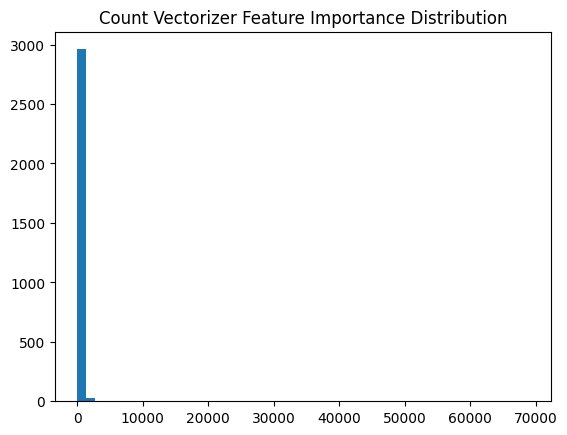

In [36]:
import matplotlib.pyplot as plt

plt.hist(np.sum(X2.toarray(), axis=0), bins=50)
plt.title("Count Vectorizer Feature Importance Distribution")
plt.show()

# Character n-grams

In [37]:
char_features = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 4),
    max_features=2000,
    min_df=2,
    max_df=0.90
)
X3 = char_features.fit_transform(df['clean_text'])

In [38]:
print(X3.shape)
print(char_features.get_feature_names_out()[:20])

(20334, 2000)
[' <' ' <c' ' <cu' ' <n' ' <nu' ' a' ' ac' ' acc' ' ad' ' add' ' ag' ' al'
 ' als' ' am' ' an' ' any' ' ap' ' app' ' ar' ' as']


In [39]:
import pandas as pd

df_char = pd.DataFrame(
    X3.toarray(),
    columns=char_features.get_feature_names_out()
)

df_char.head(10)

,<,<c,<cu,<n,<nu,a,ac,acc,ad,add,...,ye,yea,year,yo,yp,ys,yst,yt,ze,ze
0,0.000000,0.0,0.0,0.000000,0.000000,0.020866,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.023194,0.0,0.0,0.000000,0.000000
1,0.000000,0.0,0.0,0.000000,0.000000,0.042329,0.000000,0.000000,0.000000,0.000000,...,0.080774,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000
2,0.095501,0.0,0.0,0.095609,0.095609,0.073443,0.000000,0.000000,0.036887,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000
3,0.098270,0.0,0.0,0.098381,0.098381,0.047232,0.000000,0.000000,0.071168,0.057358,...,0.000000,0.0,0.0,0.027059,0.0,0.000000,0.0,0.0,0.000000,0.000000
4,0.000000,0.0,0.0,0.000000,0.000000,0.034038,0.000000,0.000000,0.000000,0.000000,...,0.064953,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000
5,0.051640,0.0,0.0,0.051699,0.051699,0.066187,0.033180,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.037918,0.0,0.000000,0.0,0.0,0.039738,0.042738
6,0.040404,0.0,0.0,0.040450,0.040450,0.019420,0.019471,0.022832,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.021587,0.0,0.0,0.000000,0.000000
7,0.045380,0.0,0.0,0.045432,0.045432,0.043623,0.000000,0.000000,0.043820,0.000000,...,0.041622,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000
8,0.208629,0.0,0.0,0.208866,0.208866,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.021892,0.023545
9,0.045485,0.0,0.0,0.045537,0.045537,0.043724,0.000000,0.000000,0.043921,0.000000,...,0.041718,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000


In [40]:
print("Non-zero values:", (X3 != 0).sum())
print("Total values:", X3.shape[0] * X3.shape[1])
print("Non-zero ratio:", ((X3 != 0).sum())/(X3.shape[0] * X3.shape[1]))

Non-zero values: 4968265
Total values: 40668000
Non-zero ratio: 0.12216644536244713


In [41]:
import numpy as np

sparsity_char = np.mean(X3.toarray() == 0)
print("Char N-grams Sparsity:", sparsity_char)

Char N-grams Sparsity: 0.8778335546375529


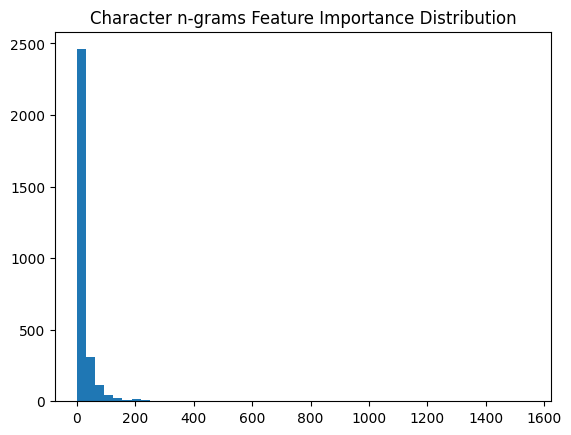

In [42]:
import matplotlib.pyplot as plt

plt.hist(np.sum(X1.toarray(), axis=0), bins=50)
plt.title("Character n-grams Feature Importance Distribution")
plt.show()

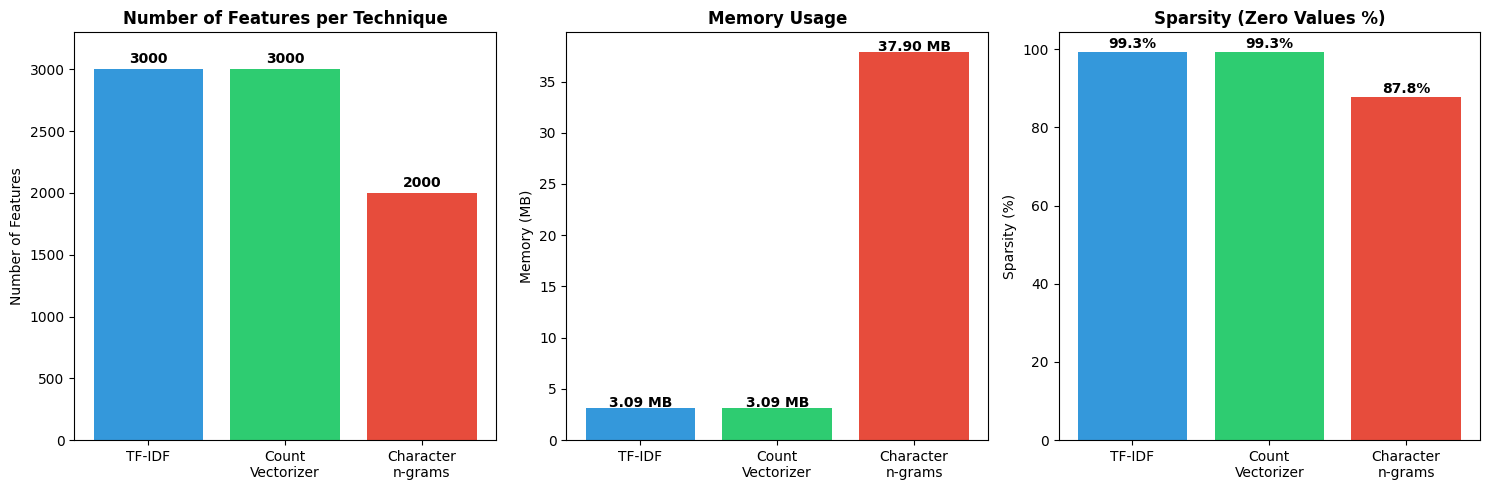

In [43]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Number of Features
techniques = ['TF-IDF', 'Count\nVectorizer', 'Character\nn-grams']
features_count = [X1.shape[1], X2.shape[1], X3.shape[1]]
axes[0].bar(techniques, features_count, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_title('Number of Features per Technique', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Features')
axes[0].set_ylim(0, max(features_count) * 1.1)
for i, v in enumerate(features_count):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 2: Memory Usage
memory_usage = [
    X1.data.nbytes / 1024 / 1024,
    X2.data.nbytes / 1024 / 1024,
    X3.data.nbytes / 1024 / 1024
]
axes[1].bar(techniques, memory_usage, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1].set_title('Memory Usage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Memory (MB)')
for i, v in enumerate(memory_usage):
    axes[1].text(i, v + 0.1, f'{v:.2f} MB', ha='center', fontweight='bold')

# Plot 3: Sparsity
sparsity = [
    (1 - X1.nnz / (X1.shape[0] * X1.shape[1])) * 100,
    (1 - X2.nnz / (X2.shape[0] * X2.shape[1])) * 100,
    (1 - X3.nnz / (X3.shape[0] * X3.shape[1])) * 100
]
axes[2].bar(techniques, sparsity, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[2].set_title('Sparsity (Zero Values %)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Sparsity (%)')
for i, v in enumerate(sparsity):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# POS TAG FEATURES (part of speech)

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize

In [45]:
def get_pos_features(text):
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)

    noun = sum(1 for w, t in tags if t.startswith('NN'))
    verb = sum(1 for w, t in tags if t.startswith('VB'))
    adj  = sum(1 for w, t in tags if t.startswith('JJ'))

    total = len(tokens)
    if total == 0:
        return [0, 0, 0]

    # normalization (important fix)
    return [
        noun / total,
        verb / total,
        adj / total
    ]


X4 = np.array(df['clean_text'].apply(get_pos_features).tolist())

# LENGTH-BASED FEATURES

In [46]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['char_count'] = df['clean_text'].apply(len)

df['digit_count'] = df['clean_text'].apply(
    lambda x: sum(c.isdigit() for c in x)
)

df['url_count'] = df['clean_text'].apply(
    lambda x: x.count('<url>')
)

X5 = df[['word_count', 'char_count', 'digit_count', 'url_count']].values

In [47]:
print("HANDCRAFTED FEATURE ENGINEERING\n")

print(f"{'Technique':<25} {'Samples':<10} {'Features':<10}")
print(f"{'POS tagging':<25} {X4.shape[0]:<10} {X4.shape[1]:<10}")
print(f"{'Length-based':<25} {X5.shape[0]:<10} {X5.shape[1]:<10}")

HANDCRAFTED FEATURE ENGINEERING

Technique                 Samples    Features  
POS tagging               20334      3         
Length-based              20334      4         


In [48]:
print("\nFEATURE EXAMPLES\n")

print("\nPOS Features:")
print(pd.DataFrame(X4, columns=['noun','verb','adj']).head())

print("Length-based Features:")
print(pd.DataFrame(X5, columns=['word_count','char_count','digit_count','url_count']).head())


FEATURE EXAMPLES


POS Features:
       noun      verb       adj
0  0.520000  0.106667  0.293333
1  0.507937  0.206349  0.238095
2  0.666667  0.148148  0.148148
3  0.805556  0.027778  0.138889
4  0.611111  0.055556  0.222222
Length-based Features:
   word_count  char_count  digit_count  url_count
0          75         584            0          0
1          63         496            0          0
2          44         290            0          0
3          54         373            0          0
4          18         118            0          0


## Repitition & Unique ( Behavioral)

In [49]:
def repetition_score(text):
    words = text.split()
    if len(words) == 0:
        return 0
    counts = Counter(words)
    return max(counts.values()) / len(words)


def unique_ratio(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)


df['repetition_score'] = df['clean_text'].apply(repetition_score)
df['unique_ratio'] = df['clean_text'].apply(unique_ratio)

X6 = df[['repetition_score', 'unique_ratio']].values

In [50]:
print("\nBEHAVIORAL FEATURE ENGINEERING\n")
print(f"{'Technique':<25} {'Samples':<10} {'Features':<10}")
print(f"{'Repetition + Unique':<25} {X6.shape[0]:<10} {X6.shape[1]:<10}")


BEHAVIORAL FEATURE ENGINEERING

Technique                 Samples    Features  
Repetition + Unique       20334      2         


In [51]:
print("\nBehavioral Features:")
print(pd.DataFrame(X6, columns=['repetition_score','unique_ratio']).head())


Behavioral Features:
   repetition_score  unique_ratio
0          0.040000      0.840000
1          0.047619      0.904762
2          0.113636      0.886364
3          0.166667      0.574074
4          0.111111      0.944444


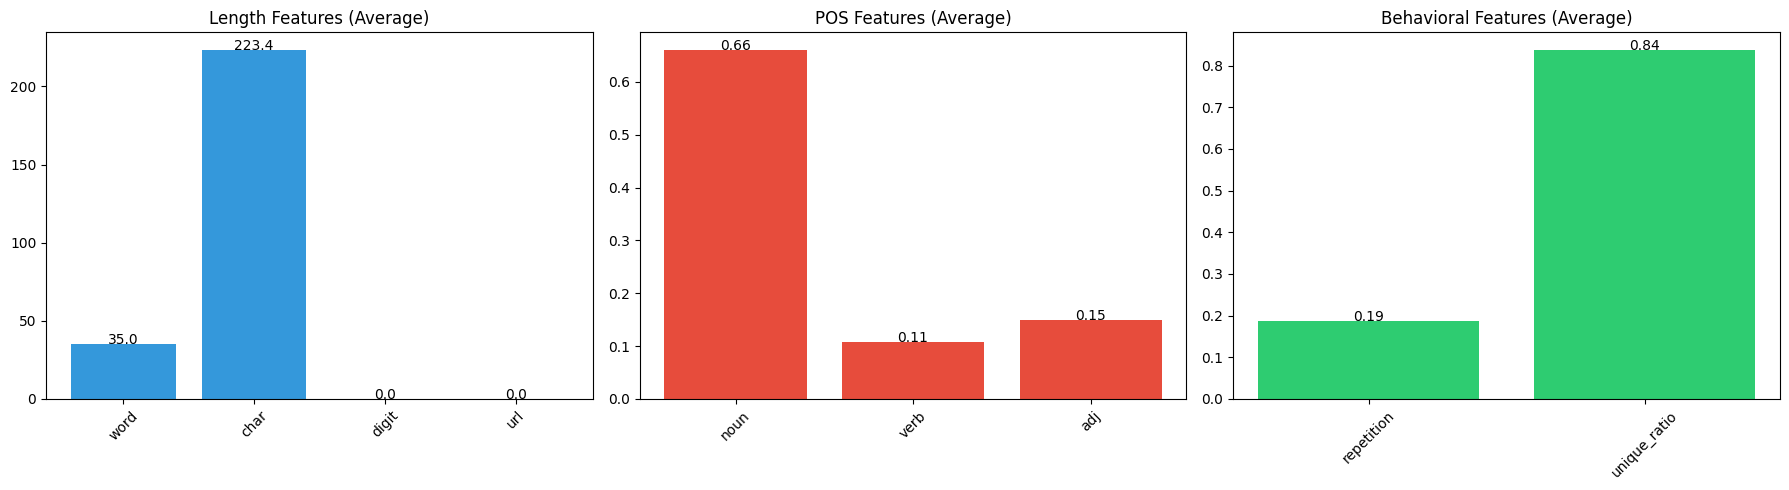

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------- POS --------
pos_labels = ['noun', 'verb', 'adj']
pos_values = X4.mean(axis=0)

axes[1].bar(pos_labels, pos_values, color='#e74c3c')
axes[1].set_title('POS Features (Average)')
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(pos_values):
    axes[1].text(i, v, f"{v:.2f}", ha='center')

# -------- Length --------
length_labels = ['word', 'char', 'digit', 'url']
length_values = X5.mean(axis=0)

axes[0].bar(length_labels, length_values, color='#3498db')
axes[0].set_title('Length Features (Average)')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(length_values):
    axes[0].text(i, v, f"{v:.1f}", ha='center')


# -------- Behavioral --------
beh_labels = ['repetition', 'unique_ratio']
beh_values = X6.mean(axis=0)

axes[2].bar(beh_labels, beh_values, color='#2ecc71')
axes[2].set_title('Behavioral Features (Average)')
axes[2].tick_params(axis='x', rotation=45)

for i, v in enumerate(beh_values):
    axes[2].text(i, v, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

In [53]:
# Text representations
X_text = {
    "TF-IDF": X1,
    "Count": X2,
    "Char": X3,
    "POS": X4,
    "Length": X5,
    "Behavior": X6
}

In [54]:
print(df['text_type'].value_counts())

text_type
ham     14323
spam     6011
Name: count, dtype: int64


In [55]:
df['text_type'] = df['text_type'].map({'ham': 0, 'spam': 1})
y = df['text_type']

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(X, y, name):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(
        max_iter=2000,
        solver='liblinear'
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print(f"{name} Accuracy: {acc:.4f}")
    return acc

In [57]:
scores = {}

scores["TF-IDF"] = evaluate(X1, y, "TF-IDF")
scores["Count"] = evaluate(X2, y, "Count")
scores["Char"] = evaluate(X3, y, "Char")
scores["POS"] = evaluate(X4, y, "POS")
scores["Length"] = evaluate(X5, y, "Length")
scores["Behavior"] = evaluate(X6, y, "Behavior")

TF-IDF Accuracy: 0.9302
Count Accuracy: 0.9361
Char Accuracy: 0.9031
POS Accuracy: 0.7045
Length Accuracy: 0.7040
Behavior Accuracy: 0.7081


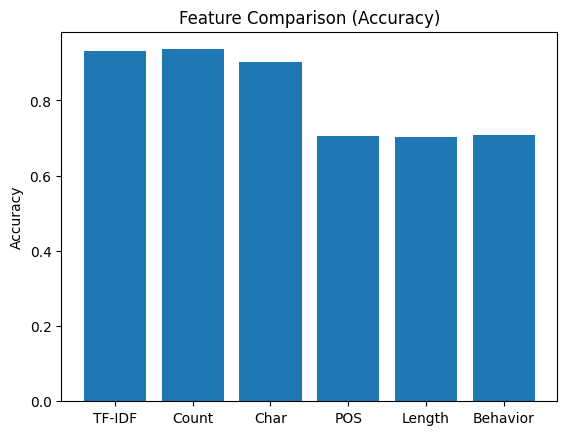

In [58]:
import matplotlib.pyplot as plt

plt.bar(scores.keys(), scores.values())
plt.title("Feature Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.show()

In [59]:
best_feature = max(scores, key=scores.get)
print("Best Feature:", best_feature)

Best Feature: Count


In [60]:
from scipy.sparse import hstack

final = hstack([X2, X1, X3])

# Model

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

X_train, X_test, y_train, y_test = train_test_split(
    final, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'max_depth'       : [3, 5, 6],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',       
    n_jobs=-1,
    verbose=1           
)

print("Running GridSearchCV... this may take a few minutes")
grid_search.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(grid_search.best_params_)
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

xgb_model = grid_search.best_estimator_
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test, xgb_preds):.4f}")
print(f"Precision : {precision_score(y_test, xgb_preds):.4f}")
print(f"Recall    : {recall_score(y_test, xgb_preds):.4f}")
print(f"F1        : {f1_score(y_test, xgb_preds):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, xgb_proba):.4f}")
print()
print(classification_report(y_test, xgb_preds, target_names=["ham", "spam"]))

Running GridSearchCV... this may take a few minutes
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best Parameters Found:
{'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 300}
Best CV F1 Score: 0.8929
XGBoost
Accuracy  : 0.9361
Precision : 0.9205
Recall    : 0.8577
F1        : 0.8880
ROC-AUC   : 0.9818

              precision    recall  f1-score   support

         ham       0.94      0.97      0.96      2865
        spam       0.92      0.86      0.89      1202

    accuracy                           0.94      4067
   macro avg       0.93      0.91      0.92      4067
weighted avg       0.94      0.94      0.94      4067



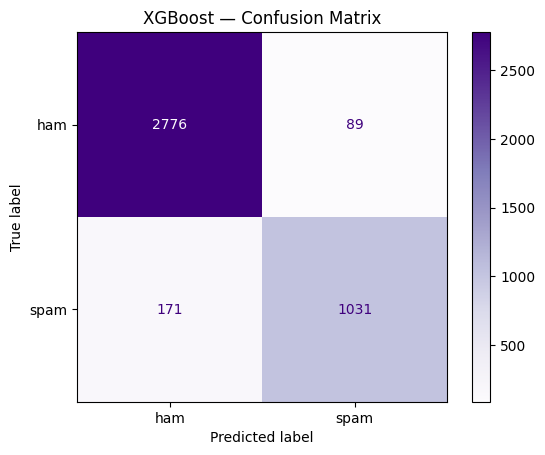

In [ ]:
## Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_preds)
ConfusionMatrixDisplay(cm_xgb, display_labels=["ham", "spam"]).plot(cmap="Purples")
plt.title("XGBoost — Confusion Matrix")
plt.show()

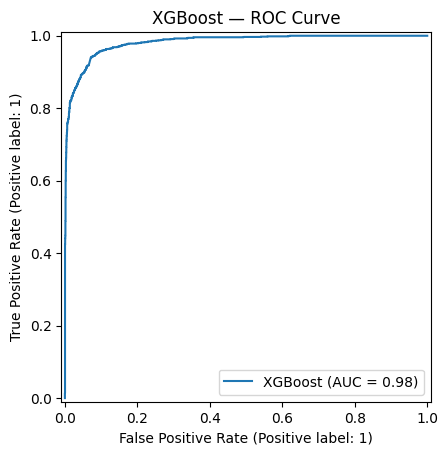

In [64]:
## ROC Curve
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, name="XGBoost")
plt.title("XGBoost — ROC Curve")
plt.show()

In [65]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_model = CalibratedClassifierCV(
    LinearSVC(max_iter=3000, C=1.0),
    cv=3
)

svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)
svm_proba = svm_model.predict_proba(X_test)[:, 1]

print("SVM (Linear)")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, svm_preds):.4f}")
print(f"Precision : {precision_score(y_test, svm_preds):.4f}")
print(f"Recall    : {recall_score(y_test, svm_preds):.4f}")
print(f"F1        : {f1_score(y_test, svm_preds):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, svm_proba):.4f}")
print()
print(classification_report(y_test, svm_preds, target_names=["ham", "spam"]))

SVM (Linear)
Accuracy  : 0.9366
Precision : 0.9322
Recall    : 0.8469
F1        : 0.8875
ROC-AUC   : 0.9753

              precision    recall  f1-score   support

         ham       0.94      0.97      0.96      2865
        spam       0.93      0.85      0.89      1202

    accuracy                           0.94      4067
   macro avg       0.94      0.91      0.92      4067
weighted avg       0.94      0.94      0.94      4067



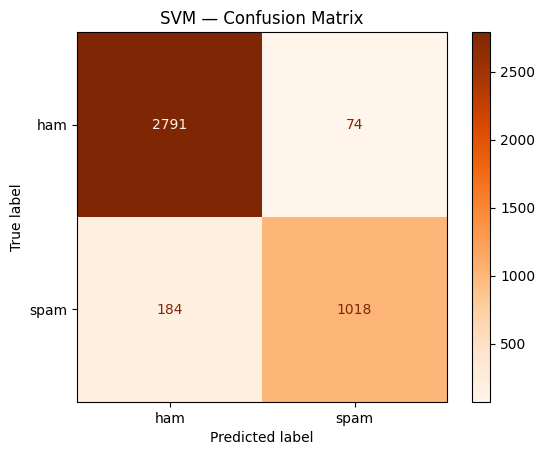

In [66]:
## Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_preds)
ConfusionMatrixDisplay(cm_svm, display_labels=["ham", "spam"]).plot(cmap="Oranges")
plt.title("SVM — Confusion Matrix")
plt.show()

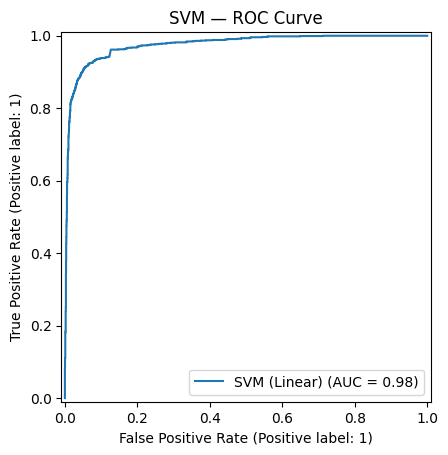

In [67]:
## ROC Curve
RocCurveDisplay.from_estimator(svm_model, X_test, y_test, name="SVM (Linear)")
plt.title("SVM — ROC Curve")
plt.show()